<a href="https://colab.research.google.com/github/Lunasgogoi/FYP/blob/main/FYP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
!nvidia-smi

Fri Oct  2 05:28:07 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   39C    P8             11W /   70W |       0MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
from pathlib import Path

BASE = Path("/content/drive/MyDrive/RoadDamageFYP")

RAW = BASE / "data/raw"
DATASET = BASE / "data/yolo_india"
RUNS = BASE / "runs"

RAW.mkdir(parents=True, exist_ok=True)
DATASET.mkdir(parents=True, exist_ok=True)
RUNS.mkdir(parents=True, exist_ok=True)

print(BASE)

/content/drive/MyDrive/RoadDamageFYP


In [ ]:
!pip install -q ultralytics opencv-python-headless lxml pyyaml

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 46.7/46.7 kB 3.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 36.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 95.2/95.2 kB 9.8 MB/s eta 0:00:00


In [ ]:
import ultralytics
import cv2
import torch

print("Ultralytics:", ultralytics.__version__)
print("OpenCV:", cv2.__version__)
print("PyTorch:", torch.__version__)
print("CUDA:", torch.cuda.is_available())

Creating new Ultralytics Settings v0.0.8 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/usage/settings.
Ultralytics: 8.4.171
OpenCV: 4.14.0
PyTorch: 2.11.0+cu130
CUDA: True


In [ ]:
zip_path = RAW / "archive (2).zip"

print("Path:", zip_path)
print("Exists:", zip_path.exists())

if zip_path.exists():
    print("Size:", zip_path.stat().st_size / (1024 * 1024), "MB")

Path: /content/drive/MyDrive/RoadDamageFYP/data/raw/archive (2).zip
Exists: True
Size: 474.0 MB


In [ ]:
import zipfile

print(zipfile.is_zipfile(zip_path))

False


In [ ]:
!pip install -q kagglehub

In [ ]:
import kagglehub

path = kagglehub.dataset_download("badri467/mwpd-rdd-india-japan-dataset")

print("Dataset downloaded to:")
print(path)

100%|██████████| 1.05G/1.05G [00:11<00:00, 98.1MB/s]

Extracting files...


Dataset downloaded to:
/root/.cache/kagglehub/datasets/badri467/mwpd-rdd-india-japan-dataset/versions/1


In [ ]:
from pathlib import Path

root = Path(path)

for p in root.rglob("*"):
    if p.is_dir() and p.name == "RDD_Combined":
        DATASET = p
        break

print(DATASET)

/root/.cache/kagglehub/datasets/badri467/mwpd-rdd-india-japan-dataset/versions/1/RDD_Combined


In [ ]:
print((DATASET / "images/train").exists())
print((DATASET / "images/val").exists())
print((DATASET / "labels/train").exists())
print((DATASET / "labels/val").exists())

True
True
True
True


In [ ]:
TRAIN_IMAGES = DATASET / "images/train"
VAL_IMAGES = DATASET / "images/val"

TRAIN_LABELS = DATASET / "labels/train"
VAL_LABELS = DATASET / "labels/val"

In [ ]:
print("Train images:", len(list(TRAIN_IMAGES.glob("*"))))
print("Train labels:", len(list(TRAIN_LABELS.glob("*.txt"))))

print("Val images:", len(list(VAL_IMAGES.glob("*"))))
print("Val labels:", len(list(VAL_LABELS.glob("*.txt"))))

Train images: 13359
Train labels: 13359
Val images: 1805
Val labels: 1805


In [ ]:
class_ids = set()

for label_file in list(TRAIN_LABELS.glob("*.txt")) + list(VAL_LABELS.glob("*.txt")):
    with open(label_file) as f:
        for line in f:
            if line.strip():
                class_ids.add(int(float(line.split()[0])))

print("Class IDs:", sorted(class_ids))

Class IDs: [0, 1, 2, 3]


In [ ]:
yaml_files = list(DATASET.rglob("*.yaml")) + list(DATASET.rglob("*.yml"))

print(yaml_files)

[]


In [ ]:
import cv2
import matplotlib.pyplot as plt

names_temp = {
    0: "Class 0",
    1: "Class 1",
    2: "Class 2",
    3: "Class 3"
}

samples = {}

for label_path in TRAIN_LABELS.glob("*.txt"):
    with open(label_path) as f:
        lines = [x.strip() for x in f if x.strip()]

    for line in lines:
        cls = int(float(line.split()[0]))

        if cls not in samples:
            img_path = None

            for ext in [".jpg", ".jpeg", ".png", ".JPG", ".PNG"]:
                p = TRAIN_IMAGES / (label_path.stem + ext)
                if p.exists():
                    img_path = p
                    break

            if img_path:
                samples[cls] = (img_path, label_path)

    if len(samples) == 4:
        break

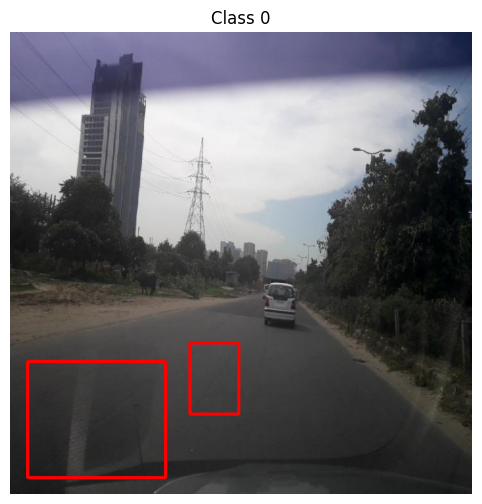

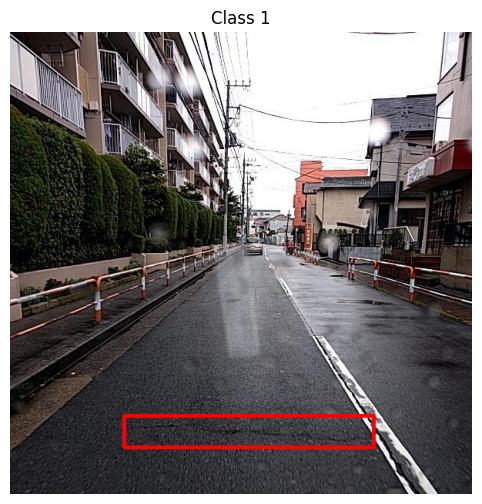

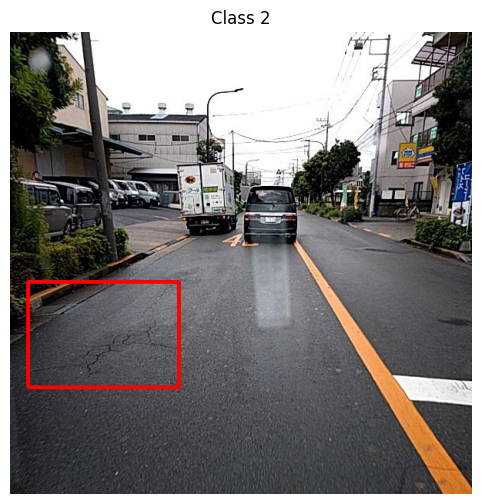

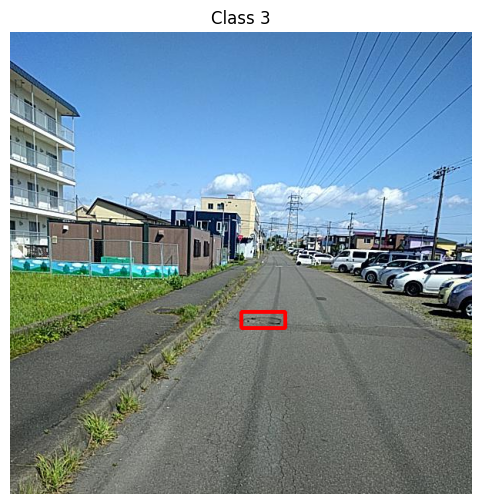

In [ ]:
for cls in sorted(samples):

    img_path, label_path = samples[cls]

    img = cv2.imread(str(img_path))
    img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

    h, w = img.shape[:2]

    with open(label_path) as f:
        for line in f:

            if not line.strip():
                continue

            c, xc, yc, bw, bh = map(float, line.split())

            if int(c) != cls:
                continue

            x1 = int((xc - bw / 2) * w)
            y1 = int((yc - bh / 2) * h)
            x2 = int((xc + bw / 2) * w)
            y2 = int((yc + bh / 2) * h)

            cv2.rectangle(img, (x1, y1), (x2, y2), (255, 0, 0), 3)

    plt.figure(figsize=(8, 6))
    plt.imshow(img)
    plt.title(f"Class {cls}")
    plt.axis("off")
    plt.show()

In [ ]:
import yaml
from pathlib import Path

names = [
    "Longitudinal Crack",
    "Transverse Crack",
    "Alligator Crack",
    "Pothole"
]

config = {
    "path": str(DATASET),
    "train": "images/train",
    "val": "images/val",
    "names": names
}

yaml_path = Path("/content/road_damage.yaml")

with open(yaml_path, "w") as f:
    yaml.safe_dump(config, f, sort_keys=False)

print(open(yaml_path).read())

path: /root/.cache/kagglehub/datasets/badri467/mwpd-rdd-india-japan-dataset/versions/1/RDD_Combined
train: images/train
val: images/val
names:
- Longitudinal Crack
- Transverse Crack
- Alligator Crack
- Pothole



In [ ]:
from collections import Counter

cnt = Counter()

for label_path in TRAIN_LABELS.glob("*.txt"):
    with open(label_path) as f:
        for line in f:
            if line.strip():
                cls = int(float(line.split()[0]))
                cnt[cls] += 1

for cls, count in sorted(cnt.items()):
    print(cls, names[cls], count)

0 Longitudinal Crack 5057
1 Transverse Crack 3683
2 Alligator Crack 7371
3 Pothole 10756


In [ ]:
import torch

print("CUDA:", torch.cuda.is_available())

if torch.cuda.is_available():
    print("GPU:", torch.cuda.get_device_name(0))

CUDA: True
GPU: Tesla T4


In [ ]:
from google.colab import drive
drive.mount("/content/drive")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
RUNS = Path("/content/drive/MyDrive/RoadDamageFYP/runs")
RUNS.mkdir(parents=True, exist_ok=True)

print(RUNS)

/content/drive/MyDrive/RoadDamageFYP/runs


In [ ]:
from ultralytics import YOLO

model = YOLO("yolov8n.pt")

model.train(
    data=str(yaml_path),
    epochs=10,
    imgsz=640,
    batch=16,
    device=0,
    project=str(RUNS),
    name="baseline_demo",
    seed=42
)

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=False, cfg=None, channels_last=None, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/road_damage.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5, dis=6.0, distill_model=None, dlam=1.0, dlog=1.0, dnn=False, dropout=0.0, dynamic=False, embed=None, epochs=10, erasing=0.4, exist_ok=False, fliplr=0.5, flipud=0.0, format=torchscript, fraction=1.0, freeze=None, hsv_h=0.015, hsv_s=0.7, hsv_v=0.4, imgsz=640, iou=0.7, kobj=1.0, line_width=None, lr0=0.01, lrf=0.01, mask_ratio=4, max_det=300, mixup=0.0, mode=train, model=yolov8n.pt, momentum=0.937, mosaic=1.0, multi_scale=0.0, name=baseline_demo, nbs=64, nms=None, opset=None, optimize=False, op

ultralytics.utils.metrics.DetMetrics object with attributes:

ap_class_index: array([0, 1, 2, 3])
box: ultralytics.utils.metrics.Metric object
confusion_matrix: <ultralytics.utils.metrics.ConfusionMatrix object at 0x7bb9563023f0>
curves: ['Precision-Recall(B)', 'F1-Confidence(B)', 'Precision-Confidence(B)', 'Recall-Confidence(B)']
curves_results: [[array([          0,    0.001001,    0.002002,    0.003003,    0.004004,    0.005005,    0.006006,    0.007007,    0.008008,    0.009009,     0.01001,    0.011011,    0.012012,    0.013013,    0.014014,    0.015015,    0.016016,    0.017017,    0.018018,    0.019019,     0.02002,    0.021021,    0.022022,    0.023023,
          0.024024,    0.025025,    0.026026,    0.027027,    0.028028,    0.029029,     0.03003,    0.031031,    0.032032,    0.033033,    0.034034,    0.035035,    0.036036,    0.037037,    0.038038,    0.039039,     0.04004,    0.041041,    0.042042,    0.043043,    0.044044,    0.045045,    0.046046,    0.047047,
          0

In [ ]:
best_path = RUNS / "baseline_demo/weights/best.pt"

baseline = YOLO(str(best_path))

print(best_path)

/content/drive/MyDrive/RoadDamageFYP/runs/baseline_demo/weights/best.pt


In [ ]:
metrics = baseline.val(
    data=str(yaml_path),
    imgsz=640
)

print(metrics.results_dict)

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.0±0.0 ms, read: 2043.8±575.7 MB/s, size: 74.1 KB)
val: Scanning /root/.cache/kagglehub/datasets/badri467/mwpd-rdd-india-japan-dataset/versions/1/RDD_Combined/labels/val.cache... 1805 images, 111 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1805/1805 504.7Mit/s 0.0s
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 5.8it/s 19.6s
                   all       1805       3840      0.542      0.477      0.501      0.236
    Longitudinal Crack        394        547      0.492      0.324      0.368      0.158
      Transverse Crack        219        364       0.45      0.319      0.322      0.127
       Alligator Crack        672        849      0.573      0.598      0.608      0.297
               Pothole        849       2080      0.6


image 1/1 /root/.cache/kagglehub/datasets/badri467/mwpd-rdd-india-japan-dataset/versions/1/RDD_Combined/images/val/Japan_img-273_jpg.rf.945e514c711d7e1725e9f1b1b4f5f18d.jpg: 640x640 1 Pothole, 11.9ms
Speed: 1.2ms preprocess, 11.9ms inference, 1.9ms postprocess per image at shape (1, 3, 640, 640)


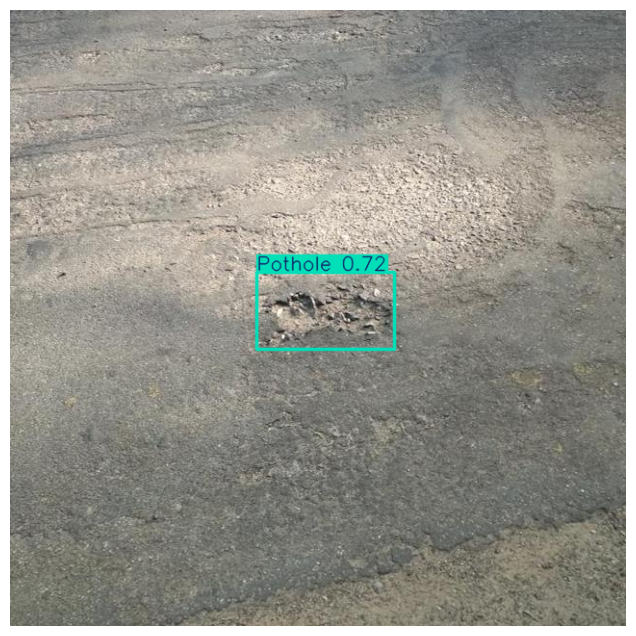

In [ ]:
import random
import cv2
import matplotlib.pyplot as plt

img_path = random.choice(list(VAL_IMAGES.glob("*")))

result = baseline.predict(
    str(img_path),
    conf=0.25
)[0]

img = cv2.cvtColor(
    result.plot(),
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(img)
plt.axis("off")
plt.show()

In [ ]:
from pathlib import Path
import cv2
import shutil

BASE = Path("/content/drive/MyDrive/RoadDamageFYP")

LR = BASE / "data/lr4"
LR_IMAGES = LR / "images/val"
LR_LABELS = LR / "labels/val"

LR_IMAGES.mkdir(parents=True, exist_ok=True)
LR_LABELS.mkdir(parents=True, exist_ok=True)

In [ ]:
for img_path in VAL_IMAGES.glob("*"):

    img = cv2.imread(str(img_path))

    if img is None:
        continue

    h, w = img.shape[:2]

    nw = max(1, w // 4)
    nh = max(1, h // 4)

    lr = cv2.resize(
        img,
        (nw, nh),
        interpolation=cv2.INTER_AREA
    )

    cv2.imwrite(
        str(LR_IMAGES / img_path.name),
        lr
    )

    label_path = VAL_LABELS / f"{img_path.stem}.txt"

    if label_path.exists():
        shutil.copy2(
            label_path,
            LR_LABELS / label_path.name
        )

print("LR images:", len(list(LR_IMAGES.glob("*"))))
print("LR labels:", len(list(LR_LABELS.glob("*.txt"))))

LR images: 1805
LR labels: 1805


In [ ]:
import yaml

lr_config = {
    "path": str(LR),
    "train": "images/val",
    "val": "images/val",
    "names": [
        "Longitudinal Crack",
        "Transverse Crack",
        "Alligator Crack",
        "Pothole"
    ]
}

lr_yaml = BASE / "road_damage_lr4.yaml"

with open(lr_yaml, "w") as f:
    yaml.safe_dump(lr_config, f, sort_keys=False)

print(open(lr_yaml).read())

path: /content/drive/MyDrive/RoadDamageFYP/data/lr4
train: images/val
val: images/val
names:
- Longitudinal Crack
- Transverse Crack
- Alligator Crack
- Pothole



In [ ]:
lr_metrics = baseline.val(
    data=str(lr_yaml),
    imgsz=640
)

print(lr_metrics.results_dict)

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 2.6±4.8 ms, read: 12.7±4.7 MB/s, size: 13.1 KB)
val: Scanning /content/drive/MyDrive/RoadDamageFYP/data/lr4/labels/val... 1805 images, 111 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1805/1805 192.7it/s 9.4s
val: New cache created: /content/drive/MyDrive/RoadDamageFYP/data/lr4/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 5.6it/s 20.2s
                   all       1805       3840      0.388      0.294       0.28      0.125
    Longitudinal Crack        394        547      0.256      0.203      0.139     0.0555
      Transverse Crack        219        364      0.206      0.151      0.105     0.0356
       Alligator Crack        672        849      0.504       0.25      0.297      0.125
               Pothole   


image 1/1 /root/.cache/kagglehub/datasets/badri467/mwpd-rdd-india-japan-dataset/versions/1/RDD_Combined/images/val/Japan_195_jpg.rf.e0254d3b4bc261ecd31e7ca33c77fd6c.jpg: 640x640 5 Potholes, 12.0ms
Speed: 1.1ms preprocess, 12.0ms inference, 1.4ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/RoadDamageFYP/data/lr4/images/val/Japan_195_jpg.rf.e0254d3b4bc261ecd31e7ca33c77fd6c.jpg: 640x640 2 Potholes, 11.9ms
Speed: 1.5ms preprocess, 11.9ms inference, 1.2ms postprocess per image at shape (1, 3, 640, 640)


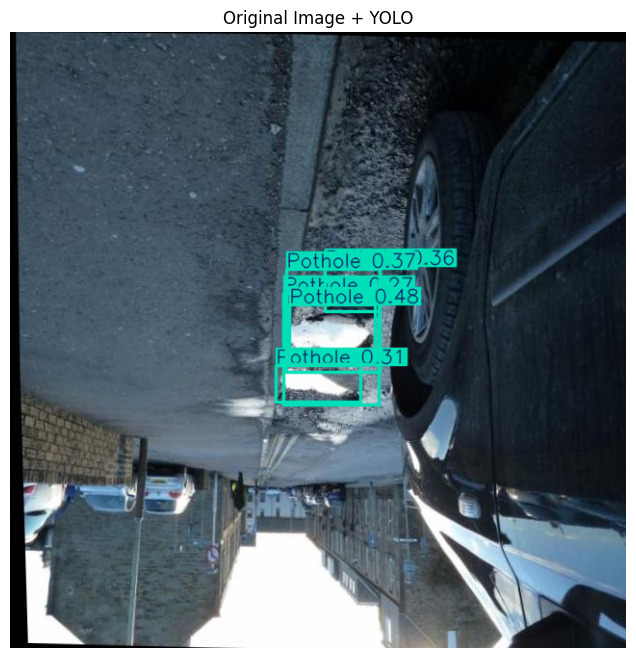

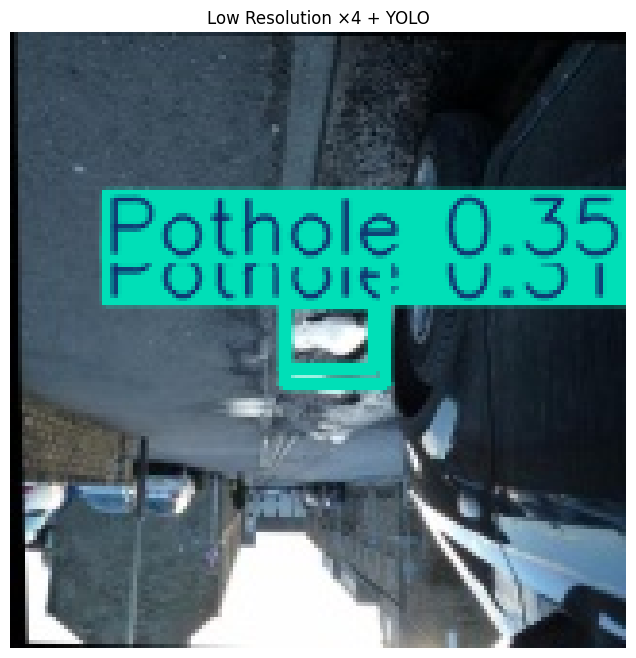

In [ ]:
import random
import matplotlib.pyplot as plt

img_path = random.choice(list(VAL_IMAGES.glob("*")))
lr_path = LR_IMAGES / img_path.name

r1 = baseline.predict(
    str(img_path),
    conf=0.25
)[0]

r2 = baseline.predict(
    str(lr_path),
    conf=0.25
)[0]

orig_plot = cv2.cvtColor(
    r1.plot(),
    cv2.COLOR_BGR2RGB
)

lr_plot = cv2.cvtColor(
    r2.plot(),
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(orig_plot)
plt.title("Original Image + YOLO")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 8))
plt.imshow(lr_plot)
plt.title("Low Resolution ×4 + YOLO")
plt.axis("off")
plt.show()

In [ ]:
print("ORIGINAL")
print(metrics.results_dict)

print("\nLOW RESOLUTION")
print(lr_metrics.results_dict)

ORIGINAL
{'metrics/precision(B)': 0.5420802099226721, 'metrics/recall(B)': 0.47696584029625183, 'metrics/mAP50(B)': 0.5013477911843148, 'metrics/mAP50-95(B)': 0.23575939334003645, 'fitness': 0.23575939334003645}

LOW RESOLUTION
{'metrics/precision(B)': 0.3879680411744179, 'metrics/recall(B)': 0.29432179375876244, 'metrics/mAP50(B)': 0.27956839794977584, 'metrics/mAP50-95(B)': 0.12481120992595514, 'fitness': 0.12481120992595514}


In [ ]:
%cd /content

!git clone https://github.com/xinntao/Real-ESRGAN.git

%cd /content/Real-ESRGAN

!pip install -q basicsr
!pip install -q facexlib
!pip install -q gfpgan
!pip install -q -r requirements.txt

!python setup.py develop

/content
fatal: destination path 'Real-ESRGAN' already exists and is not an empty directory.
/content/Real-ESRGAN
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This is an issue with the package mentioned above, not pip.
hint: See above for details.
  error: subprocess-exited-with-error
  
  × python setup.py egg_info did not run successfully.
  │ exit code: 1
  ╰─> See above for output.
  
  note: This error originates from a subprocess, and is likely not a problem with pip.
  Preparing metadata (setup.py) ... error
error: metadata-generation-failed

× Encountered error while generating package metadata.
╰─> See above for output.

note: This 

In [ ]:
!wget -q \
https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth \
-P weights

In [ ]:
from pathlib import Path

SR = BASE / "data/sr4"

SR_IMAGES = SR / "images/val"
SR_LABELS = SR / "labels/val"

SR_IMAGES.mkdir(parents=True, exist_ok=True)
SR_LABELS.mkdir(parents=True, exist_ok=True)

print(SR_IMAGES)

/content/drive/MyDrive/RoadDamageFYP/data/sr4/images/val


In [ ]:
lr_input = str(LR_IMAGES)
sr_output = str(SR_IMAGES)

print(lr_input)
print(sr_output)

/content/drive/MyDrive/RoadDamageFYP/data/lr4/images/val
/content/drive/MyDrive/RoadDamageFYP/data/sr4/images/val


In [ ]:
!python inference_realesrgan.py \
-n RealESRGAN_x4plus \
-i "$lr_input" \
-o "$sr_output" \
--outscale 4

Traceback (most recent call last):
  File "/content/Real-ESRGAN/inference_realesrgan.py", line 5, in <module>
    from basicsr.archs.rrdbnet_arch import RRDBNet
ModuleNotFoundError: No module named 'basicsr'


In [ ]:
%cd /content/Real-ESRGAN

/content/Real-ESRGAN


In [ ]:
%cd /content

!rm -rf BasicSR
!git clone https://github.com/XPixelGroup/BasicSR.git

/content
Cloning into 'BasicSR'...
remote: Enumerating objects: 5924, done.
remote: Total 5924 (delta 0), reused 0 (delta 0), pack-reused 5924 (from 1)
Receiving objects: 100% (5924/5924), 4.14 MiB | 27.33 MiB/s, done.
Resolving deltas: 100% (3757/3757), done.


In [ ]:
from pathlib import Path

p = Path("/content/BasicSR/setup.py")

txt = p.read_text()

txt = txt.replace(
    """def get_version():
    with open(version_file, 'r') as f:
        exec(compile(f.read(), version_file, 'exec'))
    return locals()['__version__']""",
    """def get_version():
    with open(version_file, 'r') as f:
        return f.read().split("'")[1]"""
)

p.write_text(txt)

print("Patched BasicSR setup.py")

Patched BasicSR setup.py


In [ ]:
%cd /content/BasicSR

!pip install -q -r requirements.txt
!pip install -q -e .

/content/BasicSR
  Preparing metadata (setup.py) ... done


In [ ]:
%cd /content/BasicSR

!pip install -q -r requirements.txt
!pip install -q -e .

/content/BasicSR
  Preparing metadata (setup.py) ... done


In [ ]:
import basicsr

print("BasicSR loaded successfully")

BasicSR loaded successfully


In [ ]:
!pip install -q facexlib gfpgan

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.2/52.2 kB 2.7 MB/s eta 0:00:00


In [ ]:
%cd /content/Real-ESRGAN

/content/Real-ESRGAN


In [ ]:
import basicsr
import facexlib
import gfpgan

print("All dependencies loaded")

All dependencies loaded


In [ ]:
import basicsr
import facexlib
import gfpgan

print("All dependencies loaded")

In [ ]:
!mkdir -p weights

!wget -q \
https://github.com/xinntao/Real-ESRGAN/releases/download/v0.1.0/RealESRGAN_x4plus.pth \
-P weights

In [ ]:
from pathlib import Path

print(
    Path(
        "/content/Real-ESRGAN/weights/RealESRGAN_x4plus.pth"
    ).exists()
)

True


In [ ]:
!python inference_realesrgan.py \
-n RealESRGAN_x4plus \
-i "$lr_input" \
-o "$sr_output" \
--outscale 4

Testing 0 India_India_000000
Testing 1 India_India_000072
Testing 2 India_India_000076
Testing 3 India_India_000147
Testing 4 India_India_000162
Testing 5 India_India_000164
Testing 6 India_India_000188
Testing 7 India_India_000207
Testing 8 India_India_000213
Testing 9 India_India_000235
Testing 10 India_India_000236
Testing 11 India_India_000238
Testing 12 India_India_000244
Testing 13 India_India_000262
Testing 14 India_India_000271
Testing 15 India_India_000286
Testing 16 India_India_000288
Testing 17 India_India_000309
Testing 18 India_India_000318
Testing 19 India_India_000358
Testing 20 India_India_000369
Testing 21 India_India_000382
Testing 22 India_India_000385
Testing 23 India_India_000408
Testing 24 India_India_000424
Testing 25 India_India_000427
Testing 26 India_India_000438
Testing 27 India_India_000443
Testing 28 India_India_000449
Testing 29 India_India_000454
Testing 30 India_India_000489
Testing 31 India_India_000493
Testing 32 India_India_000502
Testing 33 India_Ind

In [ ]:
from pathlib import Path

TEST_LR = Path("/content/test_lr")
TEST_SR = Path("/content/test_sr")

TEST_LR.mkdir(parents=True, exist_ok=True)
TEST_SR.mkdir(parents=True, exist_ok=True)

print(TEST_LR)
print(TEST_SR)

/content/test_lr
/content/test_sr


In [ ]:
import random
import shutil

sample_lr = random.choice(list(LR_IMAGES.glob("*")))

print("Selected LR image:", sample_lr)

for p in TEST_LR.glob("*"):
    p.unlink()

for p in TEST_SR.glob("*"):
    p.unlink()

shutil.copy2(
    sample_lr,
    TEST_LR / sample_lr.name
)

Selected LR image: /content/drive/MyDrive/RoadDamageFYP/data/lr4/images/val/Japan_Japan_005188.jpg


PosixPath('/content/test_lr/Japan_Japan_005188.jpg')

In [ ]:
print(list(TEST_SR.glob("*")))

[]


In [ ]:
%cd /content/Real-ESRGAN

/content/Real-ESRGAN


In [ ]:
test_lr_path = str(TEST_LR)
test_sr_path = str(TEST_SR)

In [ ]:
!python inference_realesrgan.py \
-n RealESRGAN_x4plus \
-i "$test_lr_path" \
-o "$test_sr_path" \
--outscale 4

Testing 0 Japan_Japan_005188


In [ ]:
print(list(TEST_SR.glob("*")))

[PosixPath('/content/test_sr/Japan_Japan_005188_out.jpg')]


In [ ]:
enhanced_files = list(TEST_SR.glob("*"))

enhanced_path = enhanced_files[0]

print("Enhanced image:", enhanced_path)

Enhanced image: /content/test_sr/Japan_Japan_005188_out.jpg


In [ ]:
r_sr = baseline.predict(
    str(enhanced_path),
    conf=0.25
)[0]


image 1/1 /content/test_sr/Japan_Japan_005188_out.jpg: 640x640 (no detections), 17.6ms
Speed: 8.1ms preprocess, 17.6ms inference, 11.9ms postprocess per image at shape (1, 3, 640, 640)


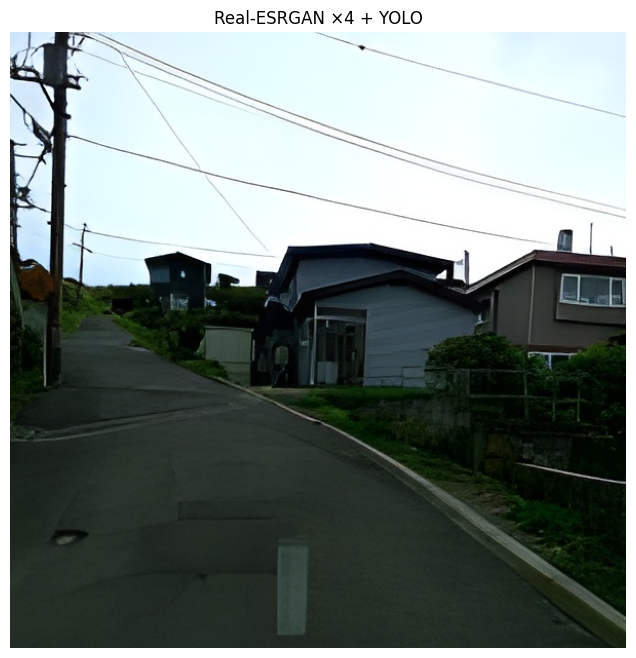

In [ ]:
import cv2
import matplotlib.pyplot as plt

sr_plot = cv2.cvtColor(
    r_sr.plot(),
    cv2.COLOR_BGR2RGB
)

plt.figure(figsize=(10, 8))
plt.imshow(sr_plot)
plt.title("Real-ESRGAN ×4 + YOLO")
plt.axis("off")
plt.show()

In [ ]:
orig_path = VAL_IMAGES / sample_lr.name

print("Original:", orig_path)
print("Low Resolution:", sample_lr)
print("Enhanced:", enhanced_path)

Original: /root/.cache/kagglehub/datasets/badri467/mwpd-rdd-india-japan-dataset/versions/1/RDD_Combined/images/val/Japan_Japan_005188.jpg
Low Resolution: /content/drive/MyDrive/RoadDamageFYP/data/lr4/images/val/Japan_Japan_005188.jpg
Enhanced: /content/test_sr/Japan_Japan_005188_out.jpg


In [ ]:
r_orig = baseline.predict(
    str(orig_path),
    conf=0.25
)[0]

r_lr = baseline.predict(
    str(sample_lr),
    conf=0.25
)[0]


image 1/1 /root/.cache/kagglehub/datasets/badri467/mwpd-rdd-india-japan-dataset/versions/1/RDD_Combined/images/val/Japan_Japan_005188.jpg: 640x640 1 Pothole, 12.0ms
Speed: 2.1ms preprocess, 12.0ms inference, 13.5ms postprocess per image at shape (1, 3, 640, 640)

image 1/1 /content/drive/MyDrive/RoadDamageFYP/data/lr4/images/val/Japan_Japan_005188.jpg: 640x640 1 Pothole, 12.0ms
Speed: 2.1ms preprocess, 12.0ms inference, 1.3ms postprocess per image at shape (1, 3, 640, 640)


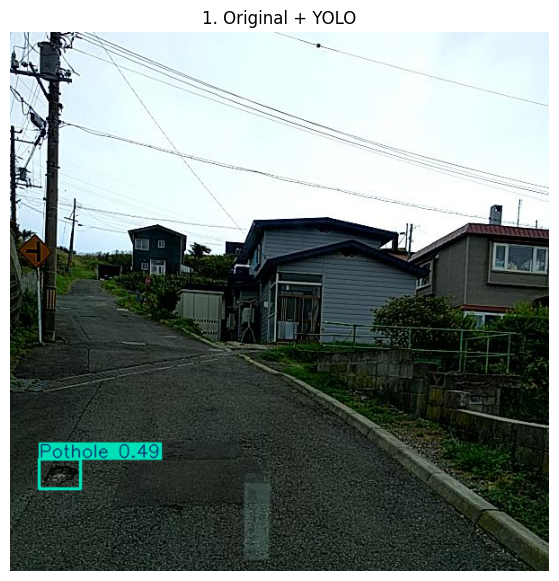

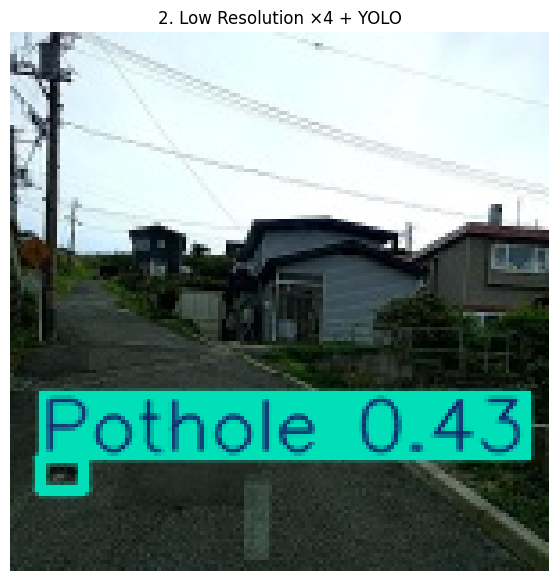

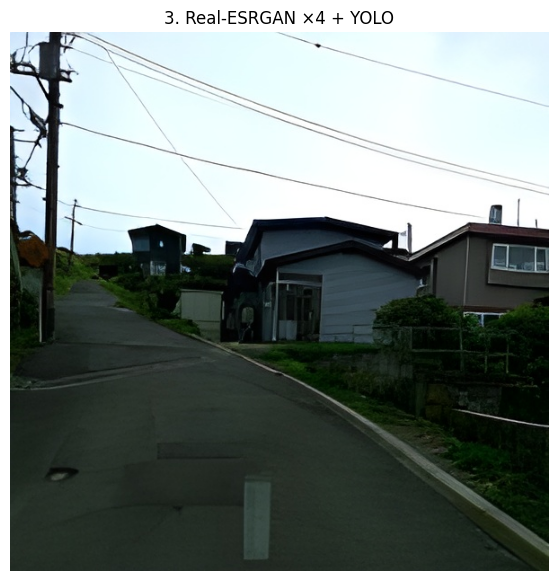

In [ ]:
orig_plot = cv2.cvtColor(r_orig.plot(), cv2.COLOR_BGR2RGB)
lr_plot = cv2.cvtColor(r_lr.plot(), cv2.COLOR_BGR2RGB)
sr_plot = cv2.cvtColor(r_sr.plot(), cv2.COLOR_BGR2RGB)

plt.figure(figsize=(10, 7))
plt.imshow(orig_plot)
plt.title("1. Original + YOLO")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 7))
plt.imshow(lr_plot)
plt.title("2. Low Resolution ×4 + YOLO")
plt.axis("off")
plt.show()

plt.figure(figsize=(10, 7))
plt.imshow(sr_plot)
plt.title("3. Real-ESRGAN ×4 + YOLO")
plt.axis("off")
plt.show()

In [ ]:
def show_info(name, result):
    print("\n" + name)
    print("-" * 35)
    print("Detections:", len(result.boxes))

    for i, box in enumerate(result.boxes):
        cls = int(box.cls[0])
        conf = float(box.conf[0])

        print(
            i + 1,
            result.names[cls],
            round(conf, 3)
        )

show_info("ORIGINAL", r_orig)
show_info("LOW RESOLUTION", r_lr)
show_info("REAL-ESRGAN", r_sr)


ORIGINAL
-----------------------------------
Detections: 1
1 Pothole 0.489

LOW RESOLUTION
-----------------------------------
Detections: 1
1 Pothole 0.426

REAL-ESRGAN
-----------------------------------
Detections: 0


In [ ]:
from pathlib import Path
import shutil

SR = BASE / "data/sr4"

SR_IMAGES = SR / "images/val"
SR_LABELS = SR / "labels/val"

SR_IMAGES.mkdir(parents=True, exist_ok=True)
SR_LABELS.mkdir(parents=True, exist_ok=True)

print(SR_IMAGES)

/content/drive/MyDrive/RoadDamageFYP/data/sr4/images/val


In [ ]:
%cd /content/Real-ESRGAN

/content/Real-ESRGAN


In [ ]:
lr_input = str(LR_IMAGES)
sr_output = str(SR_IMAGES)

print(lr_input)
print(sr_output)

/content/drive/MyDrive/RoadDamageFYP/data/lr4/images/val
/content/drive/MyDrive/RoadDamageFYP/data/sr4/images/val


In [ ]:
!python inference_realesrgan.py \
-n RealESRGAN_x4plus \
-i "$lr_input" \
-o "$sr_output" \
--outscale 4

Testing 0 India_India_000000
Testing 1 India_India_000072
Testing 2 India_India_000076
Testing 3 India_India_000147
Testing 4 India_India_000162
Testing 5 India_India_000164
Testing 6 India_India_000188
Testing 7 India_India_000207
Testing 8 India_India_000213
Testing 9 India_India_000235
Testing 10 India_India_000236
Testing 11 India_India_000238
Testing 12 India_India_000244
Testing 13 India_India_000262
Testing 14 India_India_000271
Testing 15 India_India_000286
Testing 16 India_India_000288
Testing 17 India_India_000309
Testing 18 India_India_000318
Testing 19 India_India_000358
Testing 20 India_India_000369
Testing 21 India_India_000382
Testing 22 India_India_000385
Testing 23 India_India_000408
Testing 24 India_India_000424
Testing 25 India_India_000427
Testing 26 India_India_000438
Testing 27 India_India_000443
Testing 28 India_India_000449
Testing 29 India_India_000454
Testing 30 India_India_000489
Testing 31 India_India_000493
Testing 32 India_India_000502
Testing 33 India_Ind

In [ ]:
sr_files = list(SR_IMAGES.glob("*"))

print("Enhanced images:", len(sr_files))

Enhanced images: 1805


In [ ]:
for img_path in list(SR_IMAGES.glob("*")):

    stem = img_path.stem

    if stem.endswith("_out"):
        new_stem = stem[:-4]

        new_path = img_path.with_name(
            new_stem + img_path.suffix
        )

        img_path.rename(new_path)

In [ ]:
print(list(SR_IMAGES.glob("*"))[:5])

[PosixPath('/content/drive/MyDrive/RoadDamageFYP/data/sr4/images/val/India_India_000000.jpg'), PosixPath('/content/drive/MyDrive/RoadDamageFYP/data/sr4/images/val/India_India_000072.jpg'), PosixPath('/content/drive/MyDrive/RoadDamageFYP/data/sr4/images/val/India_India_000076.jpg'), PosixPath('/content/drive/MyDrive/RoadDamageFYP/data/sr4/images/val/India_India_000147.jpg'), PosixPath('/content/drive/MyDrive/RoadDamageFYP/data/sr4/images/val/India_India_000162.jpg')]


In [ ]:
for label_path in VAL_LABELS.glob("*.txt"):

    shutil.copy2(
        label_path,
        SR_LABELS / label_path.name
    )

In [ ]:
print("SR images:", len(list(SR_IMAGES.glob("*"))))
print("SR labels:", len(list(SR_LABELS.glob("*.txt"))))

SR images: 1805
SR labels: 1805


In [ ]:
import yaml

sr_config = {
    "path": str(SR),
    "train": "images/val",
    "val": "images/val",
    "names": [
        "Longitudinal Crack",
        "Transverse Crack",
        "Alligator Crack",
        "Pothole"
    ]
}

sr_yaml = BASE / "road_damage_sr4.yaml"

with open(sr_yaml, "w") as f:
    yaml.safe_dump(
        sr_config,
        f,
        sort_keys=False
    )

print(open(sr_yaml).read())

path: /content/drive/MyDrive/RoadDamageFYP/data/sr4
train: images/val
val: images/val
names:
- Longitudinal Crack
- Transverse Crack
- Alligator Crack
- Pothole



In [ ]:
sr_metrics = baseline.val(
    data=str(sr_yaml),
    imgsz=640
)

print(sr_metrics.results_dict)

Ultralytics 8.4.171 🚀 Python-3.13.15 torch-2.11.0+cu130 CUDA:0 (Tesla T4, 14913MiB)
Model summary (fused): 72 layers, 3,006,428 parameters, 0 gradients, 8.1 GFLOPs
val: Fast image access ✅ (ping: 0.5±0.1 ms, read: 85.8±31.9 MB/s, size: 109.1 KB)
val: Scanning /content/drive/MyDrive/RoadDamageFYP/data/sr4/labels/val... 1805 images, 111 backgrounds, 0 corrupt: 100% ━━━━━━━━━━━━ 1805/1805 213.8it/s 8.4s
val: New cache created: /content/drive/MyDrive/RoadDamageFYP/data/sr4/labels/val.cache
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100% ━━━━━━━━━━━━ 113/113 4.8it/s 23.7s
                   all       1805       3840      0.369      0.278      0.251      0.111
    Longitudinal Crack        394        547      0.243      0.155      0.102     0.0391
      Transverse Crack        219        364      0.247      0.175      0.107     0.0325
       Alligator Crack        672        849      0.382      0.214      0.198     0.0775
               Pothole 

In [ ]:
def get_metrics(m):
    d = m.results_dict

    return {
        "Precision": d.get("metrics/precision(B)"),
        "Recall": d.get("metrics/recall(B)"),
        "mAP50": d.get("metrics/mAP50(B)"),
        "mAP50-95": d.get("metrics/mAP50-95(B)")
    }

print("ORIGINAL")
print(get_metrics(metrics))

print("\nLOW RESOLUTION")
print(get_metrics(lr_metrics))

print("\nREAL-ESRGAN")
print(get_metrics(sr_metrics))

ORIGINAL
{'Precision': 0.5420802099226721, 'Recall': 0.47696584029625183, 'mAP50': 0.5013477911843148, 'mAP50-95': 0.23575939334003645}

LOW RESOLUTION
{'Precision': 0.3879680411744179, 'Recall': 0.29432179375876244, 'mAP50': 0.27956839794977584, 'mAP50-95': 0.12481120992595514}

REAL-ESRGAN
{'Precision': 0.36873185537709374, 'Recall': 0.27811510117432375, 'mAP50': 0.251463774454206, 'mAP50-95': 0.11094309885231986}
